# **LAB 12**

---


# **Task 1: Basic Network Analysis**

**Algorithm**


1.   Create an empty graph
2.   Add nodes through edge insertion
3.   Count total nodes.
4.   Count total edges
5.   Compute degree centrality for each node.
6.   Compute clustering coefficient for each node.
7.   Display results.

In [2]:
import networkx as nx

# Create graph
G = nx.Graph()

# Add the following edges: (1,2), (1,3), (2,3), (3,4), (4,5), (5,6), (6,4)
G.add_edges_from([(1, 2), (1, 3), (2, 3), (3, 4), (4, 5), (5, 6), (6, 4)])

# Print number of nodes
print("Number of nodes:", G.number_of_nodes())

# Print number of edges
print("Number of edges:", G.number_of_edges())

# Calculate degree centrality
degree_centrality = nx.degree_centrality(G)

# Display degree centrality values
print("\nDegree Centrality:")
for node, cent in degree_centrality.items():
    print(f"Node {node}: {cent:.4f}")

# Calculate clustering coefficient
clustering_coefficient = nx.clustering(G)

# Display clustering coefficient values
print("\nClustering Coefficient:")
for node, coeff in clustering_coefficient.items():
    print(f"Node {node}: {coeff:.4f}")

Number of nodes: 6
Number of edges: 7

Degree Centrality:
Node 1: 0.4000
Node 2: 0.4000
Node 3: 0.6000
Node 4: 0.6000
Node 5: 0.4000
Node 6: 0.4000

Clustering Coefficient:
Node 1: 1.0000
Node 2: 1.0000
Node 3: 0.3333
Node 4: 0.3333
Node 5: 1.0000
Node 6: 1.0000


# **Task 2: Spectral Clustering**


**Algorithm**


1.   Load the Karate Club graph
2.   Convert graph into adjacency matrix.
3.   Initialize spectral clustering.
4.   Specify number of clusters.
5.   Train clustering model.
6.   Assign cluster labels.
7.   Print results.

In [3]:
import networkx as nx
from sklearn.cluster import SpectralClustering

# Load Karate Club graph
G_karate = nx.karate_club_graph()

# Convert graph into adjacency matrix
# Using to_numpy_array as it is the standard for scikit-learn compatibility
A = nx.to_numpy_array(G_karate) 

# Create Spectral Clustering model
sc = SpectralClustering(
    n_clusters = 2,
    affinity = 'precomputed', # Adjacency matrix acts as a precomputed similarity matrix
    random_state = 42
)

# Fit model and obtain cluster labels
labels = sc.fit_predict(A)

# Print node-cluster assignments
print("Node-Cluster Assignments:")
for node, label in zip(G_karate.nodes(), labels):
    print(f"Node {node} -> Cluster {label}")

Node-Cluster Assignments:
Node 0 -> Cluster 1
Node 1 -> Cluster 1
Node 2 -> Cluster 1
Node 3 -> Cluster 1
Node 4 -> Cluster 1
Node 5 -> Cluster 1
Node 6 -> Cluster 1
Node 7 -> Cluster 1
Node 8 -> Cluster 0
Node 9 -> Cluster 0
Node 10 -> Cluster 1
Node 11 -> Cluster 1
Node 12 -> Cluster 1
Node 13 -> Cluster 1
Node 14 -> Cluster 0
Node 15 -> Cluster 0
Node 16 -> Cluster 1
Node 17 -> Cluster 1
Node 18 -> Cluster 0
Node 19 -> Cluster 1
Node 20 -> Cluster 0
Node 21 -> Cluster 1
Node 22 -> Cluster 0
Node 23 -> Cluster 0
Node 24 -> Cluster 0
Node 25 -> Cluster 0
Node 26 -> Cluster 0
Node 27 -> Cluster 0
Node 28 -> Cluster 0
Node 29 -> Cluster 0
Node 30 -> Cluster 0
Node 31 -> Cluster 0
Node 32 -> Cluster 0
Node 33 -> Cluster 0


# **Task 3: Spectral Clustering Visualization**

**Algorithm**
1. Read cluster labels.
2. Assign color based on cluster.
3. Draw graph.
4. Display visualization.

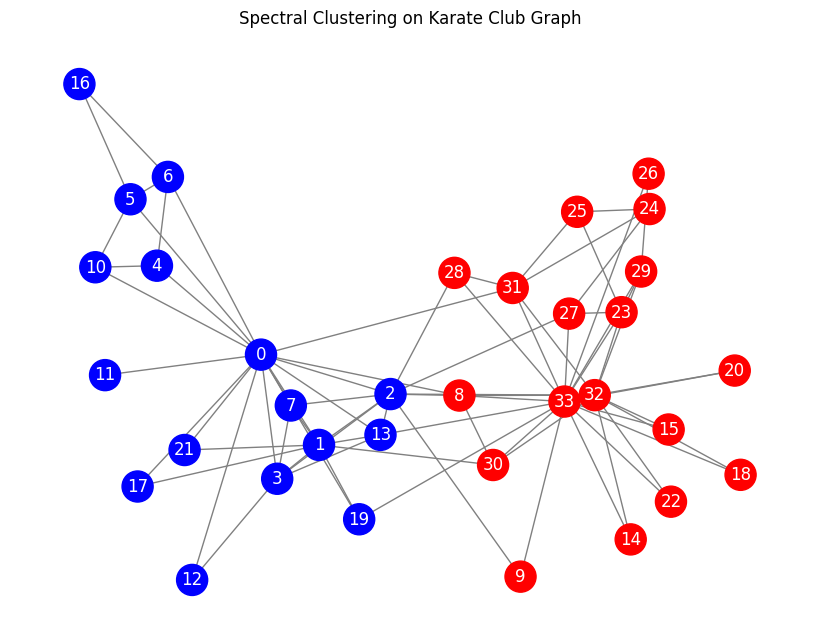

In [4]:
import matplotlib.pyplot as plt
import networkx as nx

# labels obtained from previous exercise are stored in the `labels` variable
colors = []

for label in labels:
    # If cluster = 0 → red
    # Else → blue
    if label == 0:
        colors.append('red')
    else:
        colors.append('blue')

# Draw graph using node colors
plt.figure(figsize=(8, 6))
nx.draw(G_karate, with_labels=True, node_color=colors, edge_color='gray', node_size=500, font_color='white')
plt.title("Spectral Clustering on Karate Club Graph")
plt.show()

# **LAB 13**

---



# **Task 4: Kernighan-Lin Bisection (For Graph Partitioning)**

**Algorithm**
1. Load graph.
2. Apply Kernighan-Lin bisection.
3. Divide graph into two partitions.
4. Store partitions.
5. Print partitions.

In [5]:
import networkx as nx
from networkx.algorithms.community import kernighan_lin_bisection

G_karate = nx.karate_club_graph()

# Partition graph into two groups
partition = kernighan_lin_bisection(G_karate)

# Extract group1 and group2
group1, group2 = partition

print("Partition 1:")
print(sorted(list(group1)))

print("\nPartition 2:")
print(sorted(list(group2)))

Partition 1:
[8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]

Partition 2:
[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 17, 19, 21]


# **Task 5: SimRank Similarity**

**Algorithm**
1. Construct graph.
2. Compute SimRank similarities.
3. Compare every pair of nodes.
4. Store similarity scores.
5. Print matrix.

In [6]:
import networkx as nx

G_sim = nx.Graph()

# Add edges (Using a simple graph example)
G_sim.add_edges_from([(1, 2), (1, 3), (2, 3), (3, 4), (4, 5)])

# Compute SimRank similarity matrix
simrank_matrix = nx.simrank_similarity(G_sim)

print("Similarity Matrix:\n")

# Iterate through matrix
# Print similarity scores
for node_u, similarities in simrank_matrix.items():
    for node_v, sim_score in similarities.items():
        if node_u != node_v: # Optional: Ignore self-similarity which is always 1.0
            print(f"SimRank({node_u}, {node_v}) = {sim_score:.4f}")

Similarity Matrix:

SimRank(1, 2) = 0.6204
SimRank(1, 3) = 0.5686
SimRank(1, 4) = 0.6069
SimRank(1, 5) = 0.4649
SimRank(2, 1) = 0.6204
SimRank(2, 3) = 0.5686
SimRank(2, 4) = 0.6069
SimRank(2, 5) = 0.4649
SimRank(3, 1) = 0.5686
SimRank(3, 2) = 0.5686
SimRank(3, 4) = 0.4262
SimRank(3, 5) = 0.6641
SimRank(4, 1) = 0.6069
SimRank(4, 2) = 0.6069
SimRank(4, 3) = 0.4262
SimRank(4, 5) = 0.3486
SimRank(5, 1) = 0.4649
SimRank(5, 2) = 0.4649
SimRank(5, 3) = 0.6641
SimRank(5, 4) = 0.3486


# **Task 6: Community Detection Using SimRank**

**Algorithm**
1. Define similarity threshold.
2. Start with an empty community list.
3. Select an unvisited node.
4. Compare it with all other nodes.
5. Add nodes whose similarity exceeds threshold.
6. Mark those nodes as visited.
7. Save community.
8. Repeat until all nodes are processed.
9. Display detected communities.

In [7]:
threshold = 0.6

communities = []
visited = set()

for node in G_sim.nodes():

    if node in visited:
        continue

    community = [node]

    # Compare node with every other node
    # If similarity > threshold
    # Add node to community
    for other_node in G_sim.nodes():
        if node != other_node and other_node not in visited:
            # Check the simrank score between 'node' and 'other_node'
            if simrank_matrix[node][other_node] > threshold:
                community.append(other_node)

    # Mark community nodes as visited
    visited.update(community)

    communities.append(community)

# Print communities
print(f"Detected Communities (Threshold > {threshold}):")
for i, comm in enumerate(communities):
    print(f"Community {i+1}: {comm}")

Detected Communities (Threshold > 0.6):
Community 1: [1, 2, 4]
Community 2: [3, 5]
